<a href="https://colab.research.google.com/github/iambekzodboboev/traffic-sign-recognition/blob/master/notebooks/04_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline model and experiments

Roadmap stage 5. Self-contained like the previous notebooks.

**Before running**: this notebook trains a model, so it needs a GPU.
Remember each Colab tab has its own runtime — go to Runtime > Change
runtime type > T4 GPU for *this* notebook specifically, even if you
already set it elsewhere.

**Run this in one sitting**: use Runtime > Run all rather than stopping
between cells. Colab's free tier disconnects after a period of tab
inactivity (roughly 90 minutes), which wipes all in-memory state and
forces a full restart from the download step. If you do get disconnected
mid-run, the safest fix is Runtime > Run all from the top again — trained
model results are safely stored in MLflow on your Drive regardless, so
nothing valuable is lost, just the in-progress run.

### Setup: download the dataset (from Google Drive, authenticated)

In [5]:
from google.colab import auth
auth.authenticate_user()

import io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

FILE_ID = "1Mi0IleRucNmwnQ4g_ZEWOyBFFv4mO9ba"
ZIP_PATH = "/content/traffic_sign_dataset.zip"

drive_service = build('drive', 'v3')
request = drive_service.files().get_media(fileId=FILE_ID)

with io.FileIO(ZIP_PATH, 'wb') as fh:
    downloader = MediaIoBaseDownload(fh, request, chunksize=200 * 1024 * 1024)
    done = False
    while not done:
        status, done = downloader.next_chunk()
        print(f"Download progress: {int(status.progress() * 100)}%")

print("Download complete.")

Download progress: 1%
Download progress: 2%
Download progress: 4%
Download progress: 5%
Download progress: 7%
Download progress: 8%
Download progress: 9%
Download progress: 11%
Download progress: 12%
Download progress: 14%
Download progress: 15%
Download progress: 16%
Download progress: 18%
Download progress: 19%
Download progress: 21%
Download progress: 22%
Download progress: 23%
Download progress: 25%
Download progress: 26%
Download progress: 28%
Download progress: 29%
Download progress: 30%
Download progress: 32%
Download progress: 33%
Download progress: 35%
Download progress: 36%
Download progress: 37%
Download progress: 39%
Download progress: 40%
Download progress: 42%
Download progress: 43%
Download progress: 44%
Download progress: 46%
Download progress: 47%
Download progress: 49%
Download progress: 50%
Download progress: 51%
Download progress: 53%
Download progress: 54%
Download progress: 56%
Download progress: 57%
Download progress: 58%
Download progress: 60%
Download progress:

In [6]:
import os

EXPECTED_SIZE = 14_945_416_206
assert os.path.exists(ZIP_PATH), "Download failed: no file was written at all."
actual_size = os.path.getsize(ZIP_PATH)
print(f"Downloaded file size: {actual_size:,} bytes ({actual_size / 1e9:.2f} GB)")
assert actual_size > 1_000_000_000, "Downloaded file is far too small to be the real dataset."
print("Size check passed.")

Downloaded file size: 14,945,416,206 bytes (14.95 GB)
Size check passed.


In [7]:
!rm -rf /content/dataset
!mkdir -p /content/dataset
!unzip -q "$ZIP_PATH" -d /content/dataset
!rm "$ZIP_PATH"

from pathlib import Path
data_dir = Path('/content/dataset/Data')
assert data_dir.is_dir(), "Unzip did not produce /content/dataset/Data as expected."
class_folders = sorted(data_dir.iterdir(), key=lambda p: int(p.name))
print(f"Unzip done. Found {len(class_folders)} class folders under Data/.")

Unzip done. Found 200 class folders under Data/.


### Setup: load the split manifest, class names, and rebuild the preprocessing pipeline

(Same as `03_preprocessing.ipynb` — repeated here so this notebook is
self-contained.)

In [8]:
import urllib.request
import pandas as pd

REPO_RAW = "https://raw.githubusercontent.com/iambekzodboboev/traffic-sign-recognition/master"
urllib.request.urlretrieve(f"{REPO_RAW}/metadata/split_manifest.csv", "/content/split_manifest.csv")
urllib.request.urlretrieve(f"{REPO_RAW}/metadata/class_names.csv", "/content/class_names.csv")

manifest_df = pd.read_csv("/content/split_manifest.csv", dtype={'class_id': str})
class_names_df = pd.read_csv("/content/class_names.csv")
print(f"Manifest: {len(manifest_df)} rows, class names: {len(class_names_df)} rows")

Manifest: 116642 rows, class names: 200 rows


In [9]:
import torchvision.transforms as T
from PIL import Image

TARGET_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class LetterboxResize:
    def __init__(self, size, fill=(0, 0, 0)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        img = img.convert('RGB')
        w, h = img.size
        max_side = max(w, h)
        canvas = Image.new('RGB', (max_side, max_side), self.fill)
        canvas.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
        return canvas.resize((self.size, self.size), Image.LANCZOS)


train_transform = T.Compose([
    LetterboxResize(TARGET_SIZE),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    LetterboxResize(TARGET_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


class TrafficSignDataset(Dataset):
    def __init__(self, manifest_df, split, data_dir, transform):
        self.df = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.data_dir / row['relative_path']) as img:
            img = self.transform(img)
        return img, int(row['class_id'])


BATCH_SIZE = 64

train_dataset = TrafficSignDataset(manifest_df, 'train', data_dir, train_transform)
val_dataset = TrafficSignDataset(manifest_df, 'val', data_dir, eval_transform)
test_dataset = TrafficSignDataset(manifest_df, 'test', data_dir, eval_transform)

train_class_counts = train_dataset.df['class_id'].value_counts()
class_weights = {cid: 1.0 / count for cid, count in train_class_counts.items()}
sample_weights = train_dataset.df['class_id'].map(class_weights).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cpu':
    print("WARNING: no GPU detected. Set Runtime > Change runtime type > T4 GPU "
          "for this notebook, then re-run from the top.")

Train: 82736, Val: 18127, Test: 15779
Using device: cuda


## Step 5.1 — MLflow tracking setup

Colab's `/content` is wiped every session, so MLflow's default local
tracking store would be lost too. Instead we mount Google Drive and point
MLflow's tracking URI at a folder there — runs persist across sessions
without any extra save step.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q mlflow

import mlflow
import mlflow.pytorch
import os

MLFLOW_DIR = "/content/drive/MyDrive/traffic_sign_recognition/mlruns"
os.makedirs(MLFLOW_DIR, exist_ok=True)
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment("traffic-sign-baseline")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MLflow tracking URI: file:/content/drive/MyDrive/traffic_sign_recognition/mlruns


## Step 5.2 — Baseline CNN, sanity-checked on a tiny subset first

Before committing to a full training run, prove the model/pipeline can
actually learn, on a trivial 3-class subset.

In [13]:
import torch.nn as nn


class BaselineCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_count = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_count += images.size(0)
    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    return (total_loss / total_count, total_correct / total_count,
            torch.cat(all_preds), torch.cat(all_labels))


print("Model and training functions defined.")

Model and training functions defined.


In [14]:
tiny_classes = ['0', '1', '2']
tiny_manifest = manifest_df[manifest_df['class_id'].isin(tiny_classes)]
tiny_train_loader = DataLoader(
    TrafficSignDataset(tiny_manifest, 'train', data_dir, train_transform),
    batch_size=32, shuffle=True)
tiny_val_loader = DataLoader(
    TrafficSignDataset(tiny_manifest, 'val', data_dir, eval_transform),
    batch_size=32, shuffle=False)

tiny_model = BaselineCNN(num_classes=200).to(device)
tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    train_loss, train_acc = train_one_epoch(tiny_model, tiny_train_loader, tiny_optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(tiny_model, tiny_val_loader, criterion, device)
    print(f"Epoch {epoch + 1}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

print("\nRandom guessing among these 3 classes would be ~0.33 accuracy.")
print("If val_acc climbs well above that, the model/pipeline can learn — proceed to the full run.")

Epoch 1: train_loss=0.288 train_acc=0.936 val_loss=0.062 val_acc=0.962
Epoch 2: train_loss=0.011 train_acc=0.998 val_loss=0.018 val_acc=0.990
Epoch 3: train_loss=0.008 train_acc=0.997 val_loss=0.003 val_acc=1.000
Epoch 4: train_loss=0.004 train_acc=0.997 val_loss=0.013 val_acc=0.995
Epoch 5: train_loss=0.002 train_acc=0.999 val_loss=0.001 val_acc=1.000

Random guessing among these 3 classes would be ~0.33 accuracy.
If val_acc climbs well above that, the model/pipeline can learn — proceed to the full run.


## Step 5.3 — Train the baseline on the full dataset

This is the real run: full training set, full 200 classes, logged to
MLflow. May take a while depending on the GPU assigned — expect roughly
15-50 minutes for the epoch count below.

In [15]:
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

model = BaselineCNN(num_classes=200).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

with mlflow.start_run(run_name="baseline_cnn_15ep") as run:
    mlflow.log_params({
        "model": "BaselineCNN",
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "target_size": TARGET_SIZE,
        "optimizer": "Adam",
    })

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}: train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")
        mlflow.log_metrics({
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
        }, step=epoch)

#     mlflow.pytorch.log_model(model, "model")
#     run_id = run.info.run_id

# print(f"\nDone. MLflow run id: {run_id}")
# print(f"Random-guess baseline for 200 classes: {1/200:.4f} ({1/200*100:.2f}%)")

Epoch 1/15: train_loss=3.465 train_acc=0.153 val_loss=2.129 val_acc=0.405
Epoch 2/15: train_loss=2.495 train_acc=0.304 val_loss=1.542 val_acc=0.555
Epoch 3/15: train_loss=2.205 train_acc=0.370 val_loss=1.246 val_acc=0.650
Epoch 4/15: train_loss=2.052 train_acc=0.407 val_loss=1.043 val_acc=0.730
Epoch 5/15: train_loss=1.946 train_acc=0.434 val_loss=0.951 val_acc=0.743
Epoch 6/15: train_loss=1.852 train_acc=0.459 val_loss=0.906 val_acc=0.749
Epoch 7/15: train_loss=1.783 train_acc=0.476 val_loss=0.759 val_acc=0.796
Epoch 8/15: train_loss=1.720 train_acc=0.492 val_loss=0.760 val_acc=0.786
Epoch 9/15: train_loss=1.679 train_acc=0.505 val_loss=0.708 val_acc=0.810
Epoch 10/15: train_loss=1.581 train_acc=0.529 val_loss=0.630 val_acc=0.841
Epoch 11/15: train_loss=1.497 train_acc=0.551 val_loss=0.563 val_acc=0.847
Epoch 12/15: train_loss=1.454 train_acc=0.563 val_loss=0.562 val_acc=0.839
Epoch 13/15: train_loss=1.416 train_acc=0.574 val_loss=0.561 val_acc=0.852
Epoch 14/15: train_loss=1.387 trai

2026/07/30 10:09:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 15/15: train_loss=1.367 train_acc=0.589 val_loss=0.484 val_acc=0.878


MlflowException: If `serialization_format` is set to 'pt2', then input_example is required. It must be a numpy array or torch tensor, or a tuple/list of numpy arrays or torch tensors. This is because 'pt2' is a traced-graph format: PyTorch traces the model graph by virtually executing model.forward with the provided example input.

In [18]:
example_input = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE)

with mlflow.start_run(run_name="baseline_cnn_15ep_recovered") as run:
    mlflow.log_params({
        "model": "BaselineCNN",
        "num_epochs": 15,
        "learning_rate": 1e-3,
        "batch_size": BATCH_SIZE,
        "target_size": TARGET_SIZE,
        "optimizer": "Adam",
    })
    mlflow.pytorch.log_model(model, name="model", input_example=example_input, serialization_format="pickle")
    run_id = run.info.run_id

print(f"Recovered. MLflow run id: {run_id}")

2026/07/30 10:14:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/30 10:14:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/30 10:14:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/30 10:15:16 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

Recovered. MLflow run id: f26429e5aaa9465abb70c07be1128c4e


## Step 5.4 — Evaluate on validation set: confusion matrix and per-class accuracy

Final validation accuracy: 0.8784 (87.84%)


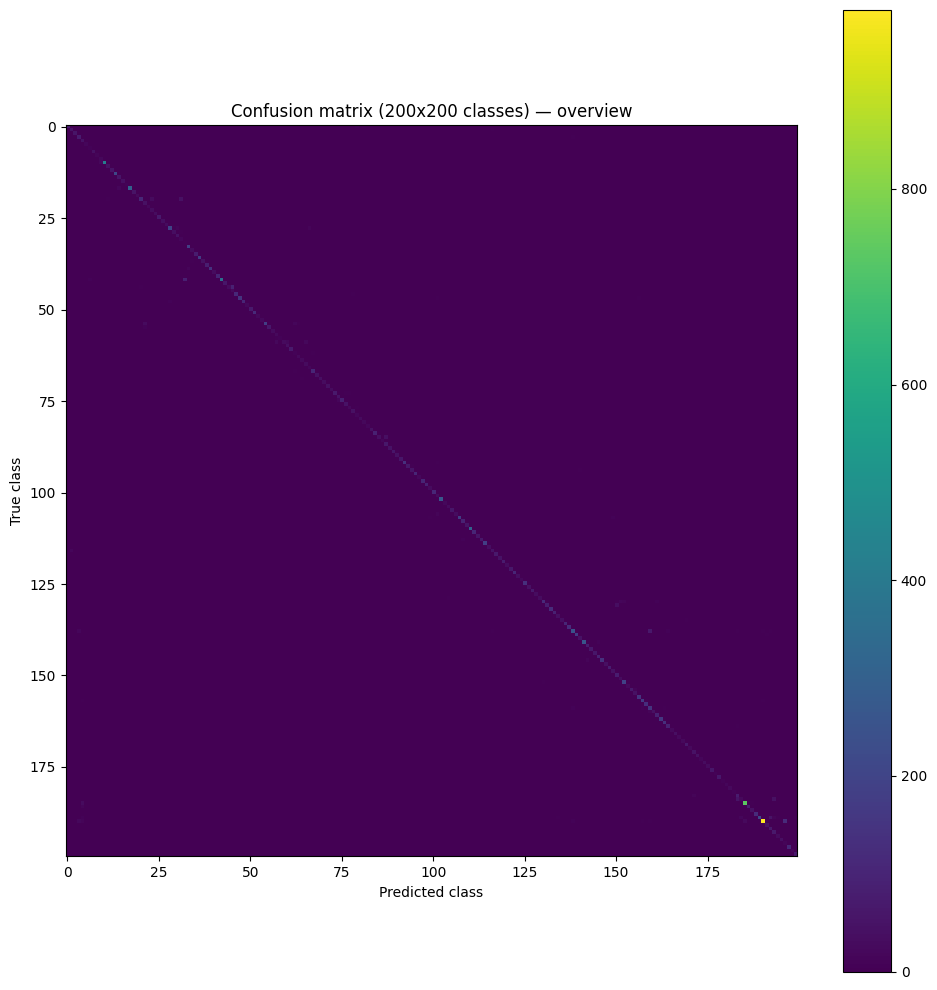

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
print(f"Final validation accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)")

cm = confusion_matrix(val_labels.numpy(), val_preds.numpy(), labels=list(range(200)))

plt.figure(figsize=(10, 10))
plt.imshow(cm, cmap='viridis')
plt.title('Confusion matrix (200x200 classes) — overview')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.colorbar()
plt.tight_layout()
plt.show()

In [19]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
class_acc_df = pd.DataFrame({
    'class_id': range(200),
    'accuracy': per_class_acc,
    'n_val_images': cm.sum(axis=1),
})
class_acc_df = class_acc_df.merge(class_names_df, on='class_id', how='left')

print("15 worst-performing classes on validation:")
print(class_acc_df.sort_values('accuracy')[['class_id', 'name', 'accuracy', 'n_val_images']]
      .head(15).to_string(index=False))

print("\n10 best-performing classes on validation:")
print(class_acc_df.sort_values('accuracy', ascending=False)[['class_id', 'name', 'accuracy', 'n_val_images']]
      .head(10).to_string(index=False))

15 worst-performing classes on validation:
 class_id                                        name  accuracy  n_val_images
      184                               Coverage area  0.179104           134
       44   Minor road three-way intersection - right  0.219697           132
       59                                Steep ascent  0.271845           103
       85                                     Customs  0.459770            87
       20                                 Curve right  0.531100           209
       58                               Steep descent  0.578947            19
       62                          Dangerous roadside  0.611111            18
      131                             End of the lane  0.661017           118
      138                        Built-up area begins  0.664042           381
      189                             Validity period  0.664577           319
      130                             Lane directions  0.680000           175
       19            

Correlation between per-class val accuracy and training set size: -0.124


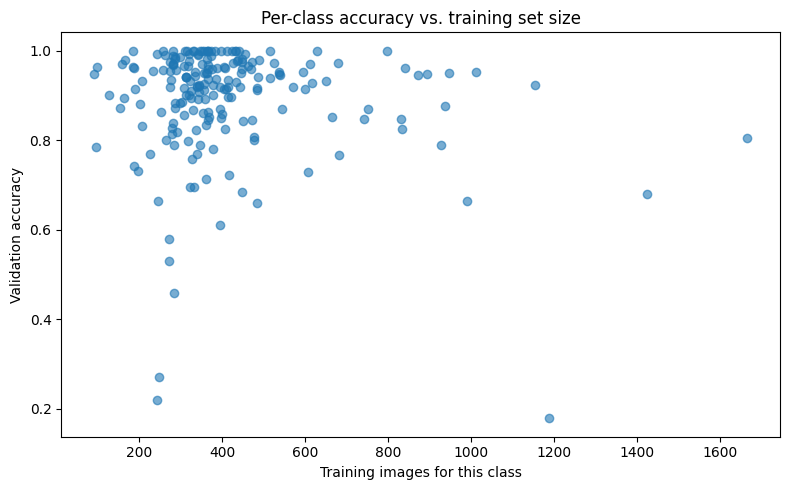

In [20]:
# Does accuracy correlate with how many training images that class had
# (the imbalance found in step 3.2)?
train_counts = train_dataset.df['class_id'].astype(int).value_counts()
class_acc_df['n_train_images'] = class_acc_df['class_id'].map(train_counts).fillna(0)

correlation = class_acc_df['accuracy'].corr(class_acc_df['n_train_images'])
print(f"Correlation between per-class val accuracy and training set size: {correlation:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(class_acc_df['n_train_images'], class_acc_df['accuracy'], alpha=0.6)
plt.xlabel('Training images for this class')
plt.ylabel('Validation accuracy')
plt.title('Per-class accuracy vs. training set size')
plt.tight_layout()
plt.show()

In [21]:
# Most-confused class pairs: which signs does the model mix up?
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
flat_idx = np.argsort(-cm_offdiag, axis=None)[:30]
top_pairs = np.dstack(np.unravel_index(flat_idx, cm_offdiag.shape))[0]

print("Most-confused class pairs (true -> predicted):")
shown = 0
for true_c, pred_c in top_pairs:
    count = cm_offdiag[true_c, pred_c]
    if count == 0 or shown >= 15:
        continue
    true_name = class_names_df.loc[class_names_df['class_id'] == true_c, 'name']
    pred_name = class_names_df.loc[class_names_df['class_id'] == pred_c, 'name']
    true_name = true_name.values[0] if len(true_name) else str(true_c)
    pred_name = pred_name.values[0] if len(pred_name) else str(pred_c)
    print(f"  {count:4d}x  true={true_c} ({true_name})  ->  predicted={pred_c} ({pred_name})")
    shown += 1

Most-confused class pairs (true -> predicted):
   122x  true=190 (Method of parking the vehicle)  ->  predicted=196 (Dangerous roadside)
    92x  true=44 (Minor road three-way intersection - right)  ->  predicted=45 (Minor road three-way intersection - left)
    85x  true=42 (End of overtaking by lorries restriction)  ->  predicted=32 (End of all restrictions)
    68x  true=138 (Built-up area begins)  ->  predicted=159 (Direction indicator)
    52x  true=184 (Coverage area)  ->  predicted=183 (Distance to the object)
    51x  true=189 (Validity period)  ->  predicted=192 (Paid services)
    46x  true=20 (Curve right)  ->  predicted=31 (Wild animals)
    46x  true=184 (Coverage area)  ->  predicted=193 (Limitation of parking duration)
    40x  true=85 (Customs)  ->  predicted=87 (Control)
    35x  true=131 (End of the lane)  ->  predicted=150 (Place for a U-turn)
    30x  true=20 (Curve right)  ->  predicted=23 (Slippery road)
    29x  true=54 (Intersection of equivalent roads)  ->  pre

### Result

This is the point to actually discuss the numbers together:
- Is overall validation accuracy clearly and meaningfully above the
  random-guess baseline (0.5% for 200 classes)?
- Does the correlation plot show weaker accuracy for classes with fewer
  training images, confirming the 3.2 imbalance is actually hurting
  those classes?
- Do the most-confused pairs make visual sense (e.g. similar-looking
  signs), or do they suggest a data/label problem?

Run this notebook, then share the results and we'll interpret them
together before deciding what to try next in stage 6 (model selection).